# SUPP-B: Biotype Breakdown of Method-Exclusive Genes

For genes found exclusively by Ensembl or exclusively by CAT,
characterise the biotype distribution and test for systematic biases.

**Input:** `intermediate_spreadsheets/gene_presence/` from workflow

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
GP_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'gene_presence'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Load pre-computed data
enrichment = pd.read_csv(GP_DIR / 'biotype_enrichment_exclusive_genes.tsv', sep='\t')
enrichment_summary = pd.read_csv(GP_DIR / 'biotype_enrichment_summary.tsv', sep='\t')

print(f"Total genes classified: {len(enrichment)}")
print(f"\nCategory counts:")
print(enrichment['category'].value_counts())
print(f"\nBiotype enrichment summary:")
display(enrichment_summary.head(20))

Total genes classified: 17197025

Category counts:
category
ensembl_exclusive    16925855
cat_exclusive          230294
concordant              40657
variable                  219
Name: count, dtype: int64

Biotype enrichment summary:


,category,biotype,n_genes,pct_of_category
0,ensembl_exclusive,lncRNA,13703010,80.96
1,ensembl_exclusive,processed_pseudogene,1469698,8.68
2,ensembl_exclusive,TEC,553100,3.27
3,ensembl_exclusive,unprocessed_pseudogene,375468,2.22
4,ensembl_exclusive,transcribed_unprocessed_pseudogene,208890,1.23
5,ensembl_exclusive,transcribed_processed_pseudogene,193912,1.15
6,ensembl_exclusive,snoRNA,152259,0.90
7,ensembl_exclusive,misc_RNA,141203,0.83
8,ensembl_exclusive,protein_coding,68378,0.40
9,ensembl_exclusive,transcribed_unitary_pseudogene,13845,0.08


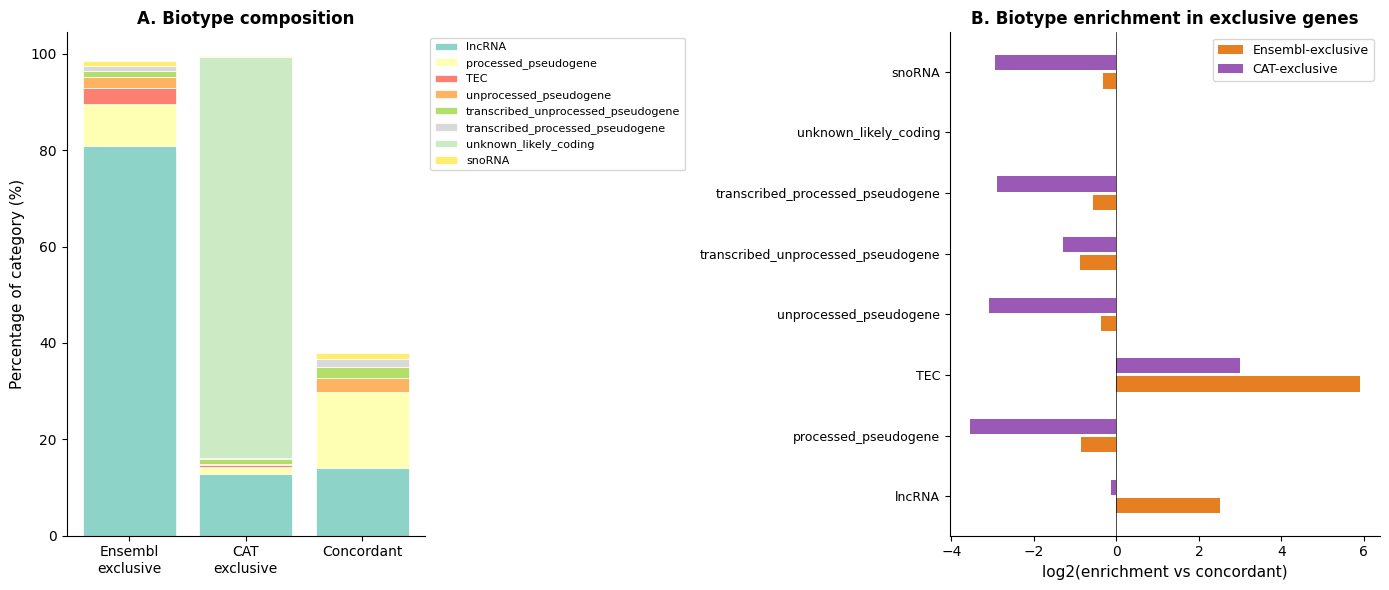

Saved to figures/figure_supp_b_biotype_exclusives.png


In [3]:
# --- SUPP-B Figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})

# Panel A: Stacked bar chart - biotype composition per category
ax = axes[0]
categories = ['ensembl_exclusive', 'cat_exclusive', 'concordant']
cat_labels = ['Ensembl\nexclusive', 'CAT\nexclusive', 'Concordant']

# Get top biotypes across all categories
top_biotypes = enrichment_summary.groupby('biotype')['n_genes'].sum().nlargest(8).index.tolist()

biotype_colors = plt.cm.Set3(np.linspace(0, 1, len(top_biotypes)))
bio_color_map = dict(zip(top_biotypes, biotype_colors))

bottom = np.zeros(len(categories))
for bio in top_biotypes:
    vals = []
    for cat in categories:
        row = enrichment_summary[(enrichment_summary['category'] == cat) & 
                                 (enrichment_summary['biotype'] == bio)]
        vals.append(row['pct_of_category'].values[0] if len(row) > 0 else 0)
    ax.bar(range(len(categories)), vals, bottom=bottom, label=bio,
           color=bio_color_map[bio], edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(range(len(cat_labels)))
ax.set_xticklabels(cat_labels, fontsize=10)
ax.set_ylabel('Percentage of category (%)', fontsize=11)
ax.set_title('A. Biotype composition', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.0, 1.0), ncol=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel B: Enrichment lollipop
ax = axes[1]

# Compute log2 enrichment ratio: exclusive / concordant for each biotype
concordant_total = len(enrichment[enrichment['category'] == 'concordant'])
enrichment_data = []

for method, cat in [('Ensembl', 'ensembl_exclusive'), ('CAT', 'cat_exclusive')]:
    method_total = len(enrichment[enrichment['category'] == cat])
    if method_total == 0 or concordant_total == 0:
        continue
    for bio in top_biotypes:
        n_method = len(enrichment[(enrichment['category'] == cat) & 
                                   (enrichment['ensembl_biotype' if method == 'Ensembl' else 'cat_biotype'] == bio)])
        n_conc = len(enrichment[(enrichment['category'] == 'concordant') & 
                                 (enrichment['ensembl_biotype'] == bio)])
        
        frac_method = n_method / method_total if method_total > 0 else 0
        frac_conc = n_conc / concordant_total if concordant_total > 0 else 0
        
        if frac_conc > 0 and frac_method > 0:
            log2_enrich = np.log2(frac_method / frac_conc)
            enrichment_data.append({
                'biotype': bio,
                'method': method,
                'log2_enrichment': log2_enrich,
                'n_exclusive': n_method,
            })

enrich_df = pd.DataFrame(enrichment_data)
if not enrich_df.empty:
    for method, color, offset in [('Ensembl', '#e67e22', -0.15), ('CAT', '#9b59b6', 0.15)]:
        subset = enrich_df[enrich_df['method'] == method]
        y = np.arange(len(top_biotypes))
        vals = [subset[subset['biotype'] == bio]['log2_enrichment'].values[0] 
                if bio in subset['biotype'].values else 0 for bio in top_biotypes]
        ax.barh(y + offset, vals, height=0.25, color=color, label=f'{method}-exclusive')

    ax.set_yticks(range(len(top_biotypes)))
    ax.set_yticklabels(top_biotypes, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('log2(enrichment vs concordant)', fontsize=11)
    ax.set_title('B. Biotype enrichment in exclusive genes', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_supp_b_biotype_exclusives.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_supp_b_biotype_exclusives.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_supp_b_biotype_exclusives.png'}")